# Does a New Landing Page Improve Conversion?
## An evidence-based A/B experiment review
**Author: Sanchita Senapati**  
**Tools:** Python · Pandas · NumPy · SciPy · Matplotlib

This project evaluates a proposed e-commerce page change using conversion rates, uncertainty intervals, and hypothesis tests. It follows the broad topic of the supplied sample, with independently written code, explanations, and visualisations.

> **Data transparency:** Only `AB_Test_Pricing_Report_CORRECTED Sir.pdf` was supplied. The default analysis recomputes overall results from its exact group counts (Table 1), not from original session records. No synthetic visitors are presented as real data. Raw-data cleaning and country analysis run only if the original CSV files are supplied. The report describes pricing pages, but the available fields cannot establish an effect on revenue, profit, or price elasticity.

### Run this notebook
Run cells from top to bottom in Jupyter, VS Code, or Google Colab. All main results work offline after dependencies are installed. Saved outputs make the analysis readable on GitHub.

Optional: place `ab_data.csv` and `countries.csv` in a `data/` folder beside the notebook, then rerun. The main analysis will use the cleaned raw data instead of the report totals.


In [1]:
# Run once if these packages are missing; then restart the kernel if needed.
# %pip install numpy pandas scipy matplotlib
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import scipy
from scipy import stats
import matplotlib
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

ALPHA = 0.05
ORDER = ['control', 'treatment']
COLORS = ['#285E8E', '#E28A3B']
plt.rcParams.update({'figure.figsize': (9, 4.5), 'axes.spines.top': False,
                     'axes.spines.right': False, 'font.size': 11})
print(f'Python {sys.version.split()[0]} | pandas {pd.__version__} | '
      f'NumPy {np.__version__} | SciPy {scipy.__version__} | Matplotlib {matplotlib.__version__}')


Python 3.12.14 | pandas 2.2.3 | NumPy 2.3.5 | SciPy 1.17.0 | Matplotlib 3.10.8


## 1. Frame the decision
**Question:** Is there evidence that changing the landing page changes the probability of conversion?

- **Control:** existing page; **treatment:** new page.
- **Outcome:** `converted`, a binary indicator (0 or 1).
- **Primary effect:** treatment conversion rate minus control conversion rate, expressed in percentage points.
- **Null hypothesis:** the population conversion rates are equal.
- **Alternative hypothesis:** the rates differ (two-sided), using a 5% significance level.

A positive, statistically supported effect would favour treatment. A business rollout would also need a prespecified minimum worthwhile lift and cost/revenue information. Those inputs are unavailable here. Tests assume independent users and a valid randomised experiment; aggregate counts cannot verify these assumptions.


## 2. Load data with an explicit audit trail
The PDF reports 145,274 control users with 17,489 conversions and 145,310 treatment users with 17,264 conversions. These exact counts are sufficient for the overall tests below.

When raw data is supplied, we validate the schema, remove incomplete/invalid records, filter assignment/page mismatches, and retain the earliest valid record per user. Filtering mismatches changes the analysed population; a production experiment should also investigate assignment logs and consider intention-to-treat analysis. Country coverage must not silently remove users from the overall comparison.


In [2]:
reported = pd.DataFrame({'group': ORDER, 'users': [145274, 145310],
                         'conversions': [17489, 17264]}).set_index('group')
raw_path = Path('data/ab_data.csv')
clean = None
country_data = None

def clean_experiment(raw):
    required = ['user_id', 'timestamp', 'group', 'landing_page', 'converted']
    missing = set(required) - set(raw.columns)
    if missing:
        raise ValueError(f'Missing columns: {sorted(missing)}')
    df = raw[required].copy()
    audit = [('Input rows', len(df))]
    df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce', utc=True)
    df['converted'] = pd.to_numeric(df['converted'], errors='coerce')
    valid = (df[required].notna().all(axis=1) & df['converted'].isin([0, 1])
             & df['group'].isin(ORDER) & df['landing_page'].isin(['old_page', 'new_page']))
    audit.append(('Incomplete or invalid rows removed', int((~valid).sum())))
    df = df.loc[valid].copy()
    matched = ((df['group'].eq('control') & df['landing_page'].eq('old_page'))
               | (df['group'].eq('treatment') & df['landing_page'].eq('new_page')))
    audit.append(('Assignment/page mismatches removed', int((~matched).sum())))
    df = df.loc[matched].sort_values('timestamp', kind='stable')
    audit.append(('Extra user records removed after filtering', int(df.duplicated('user_id').sum())))
    df = df.drop_duplicates('user_id', keep='first').copy()
    df['converted'] = df['converted'].astype(int)
    audit.append(('Final unique users', len(df)))
    assert df['user_id'].is_unique
    return df, pd.DataFrame(audit, columns=['Step', 'Rows'])

if raw_path.exists():
    clean, audit = clean_experiment(pd.read_csv(raw_path))
    display(audit)
    summary = clean.groupby('group')['converted'].agg(users='size', conversions='sum').reindex(ORDER)
    data_source = 'Original CSV, cleaned using the documented rules'
else:
    summary = reported.copy()
    data_source = 'Exact aggregate counts transcribed from the supplied PDF, Table 1'

assert summary.notna().all().all()
assert (summary['users'] > 1).all()
assert summary['conversions'].between(0, summary['users']).all()
summary['non_conversions'] = summary['users'] - summary['conversions']
summary['rate'] = summary['conversions'] / summary['users']
print('ACTIVE DATA SOURCE:', data_source)
display(summary)
print(f'Total users: {summary.users.sum():,}; conversions: {summary.conversions.sum():,}')


ACTIVE DATA SOURCE: Exact aggregate counts transcribed from the supplied PDF, Table 1
Total users: 290,584; conversions: 34,753


,users,conversions,non_conversions,rate
group,,,,
control,145274,17489,127785,0.120386
treatment,145310,17264,128046,0.118808


## 3. Conversion rates and uncertainty
For each group, a Wilson 95% confidence interval summarises uncertainty in its conversion rate. To assess the treatment effect, we later compute an interval for the **difference** directly; overlapping group intervals alone are not a formal test.


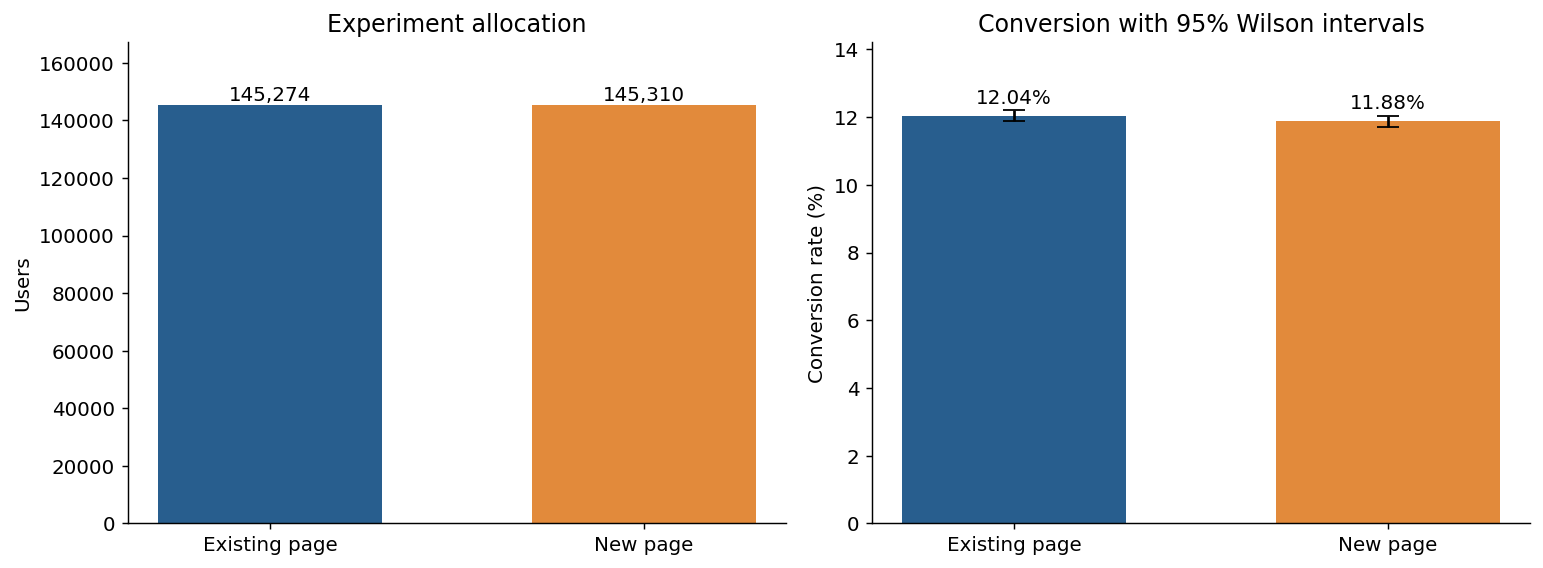

In [3]:
def wilson_interval(successes, n, alpha=ALPHA):
    p = np.asarray(successes) / np.asarray(n)
    z = stats.norm.ppf(1 - alpha / 2)
    denominator = 1 + z**2 / n
    centre = (p + z**2 / (2 * n)) / denominator
    half = z * np.sqrt(p * (1 - p) / n + z**2 / (4 * n**2)) / denominator
    return centre - half, centre + half

lo, hi = wilson_interval(summary.conversions.to_numpy(), summary.users.to_numpy())
summary['ci_low'], summary['ci_high'] = lo, hi
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].bar(['Existing page', 'New page'], summary.users, color=COLORS, width=.6)
axes[0].set(ylabel='Users', title='Experiment allocation')
for i, n in enumerate(summary.users):
    axes[0].text(i, n + 1500, f'{n:,}', ha='center')
axes[0].set_ylim(0, summary.users.max() * 1.15)
rates = summary.rate.to_numpy()
axes[1].bar(['Existing page', 'New page'], 100 * rates, color=COLORS, width=.6,
            yerr=100 * np.array([rates - lo, hi - rates]), capsize=6)
axes[1].set(ylabel='Conversion rate (%)', title='Conversion with 95% Wilson intervals')
for i, p in enumerate(rates):
    axes[1].text(i, 100 * hi[i] + .2, f'{p:.2%}', ha='center')
axes[1].set_ylim(0, max(hi) * 100 + 2)
fig.tight_layout()
plt.show()


## 4. Quantify the treatment effect
Absolute lift is the rate difference. Relative lift divides that difference by the control rate. A **percentage-point** change is different from a **percent** change.

The interval below uses a large-sample unpooled standard error. With large numbers of conversions and non-conversions in both groups, the normal approximation is appropriate.


Control conversion: 12.0386%
Treatment conversion: 11.8808%
Absolute lift: -0.1578 percentage points
Relative lift: -1.31%
95% CI of absolute lift: [-0.3938, +0.0781] pp
Observed difference per 10,000 users: -15.8 conversions


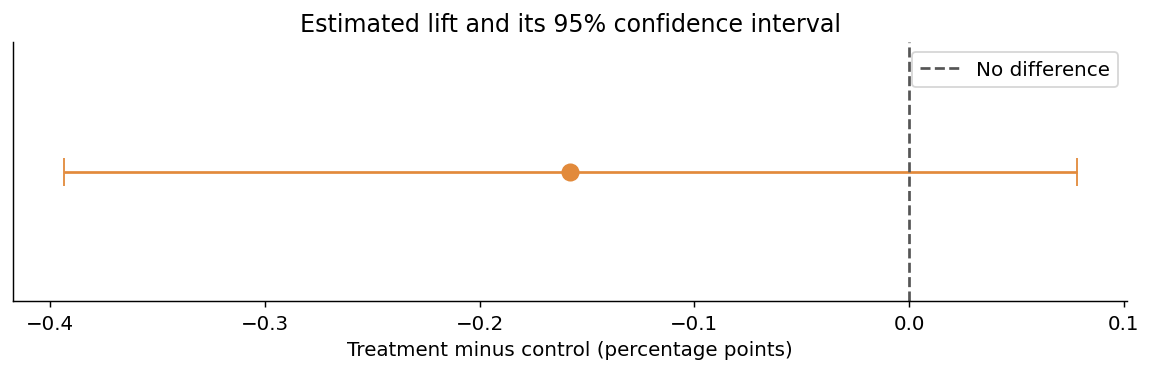

In [4]:
n_c, n_t = summary.users.to_numpy(dtype=float)
x_c, x_t = summary.conversions.to_numpy(dtype=float)
p_c, p_t = summary.rate.to_numpy()
delta = p_t - p_c
relative_lift = delta / p_c
se = np.sqrt(p_c * (1 - p_c) / n_c + p_t * (1 - p_t) / n_t)
z_critical = stats.norm.ppf(1 - ALPHA / 2)
delta_low, delta_high = delta + np.array([-1, 1]) * z_critical * se
print(f'Control conversion: {p_c:.4%}')
print(f'Treatment conversion: {p_t:.4%}')
print(f'Absolute lift: {delta * 100:+.4f} percentage points')
print(f'Relative lift: {relative_lift:+.2%}')
print(f'95% CI of absolute lift: [{delta_low * 100:+.4f}, {delta_high * 100:+.4f}] pp')
print(f'Observed difference per 10,000 users: {delta * 10000:+.1f} conversions')
fig, ax = plt.subplots(figsize=(9, 3))
ax.errorbar(delta * 100, 0, xerr=z_critical * se * 100, fmt='o',
            color=COLORS[1], capsize=8, markersize=9)
ax.axvline(0, color='#555555', linestyle='--', label='No difference')
ax.set(yticks=[], xlabel='Treatment minus control (percentage points)',
       title='Estimated lift and its 95% confidence interval')
ax.legend()
fig.tight_layout()
plt.show()


## 5. Hypothesis tests
### A. Two-proportion z-test — primary analysis
A pooled conversion rate estimates the standard error under the null hypothesis.
### B. Welch's independent-samples t-test — comparison with the sample
For binary data, the mean is the conversion rate. Exact counts determine the sample variance, so the test can be computed without fabricating individual records.
### C. Chi-square test — categorical association
The 2 × 2 table compares assignment and conversion. We show both the ordinary Pearson test and Yates' continuity-corrected version; the latter matches the convention used in the sample report.

These tests reuse the **same observations** and are not independent confirmations. The uncorrected chi-square statistic equals the squared two-proportion z-statistic for this table.


In [5]:
pooled = (x_c + x_t) / (n_c + n_t)
se_null = np.sqrt(pooled * (1 - pooled) * (1 / n_c + 1 / n_t))
z_stat = delta / se_null
z_p = 2 * stats.norm.sf(abs(z_stat))
# Unbiased sample standard deviations of binary outcomes.
sd_c = np.sqrt(p_c * (1 - p_c) * n_c / (n_c - 1))
sd_t = np.sqrt(p_t * (1 - p_t) * n_t / (n_t - 1))
t_stat, t_p = stats.ttest_ind_from_stats(p_t, sd_t, n_t, p_c, sd_c, n_c, equal_var=False)
table = summary[['non_conversions', 'conversions']].astype(int)
chi, chi_p, dof, expected = stats.chi2_contingency(table, correction=False)
chi_y, chi_y_p, _, _ = stats.chi2_contingency(table, correction=True)
assert np.allclose(chi, z_stat**2)
assert expected.min() >= 5
results = pd.DataFrame([
    ['Two-proportion z-test (primary)', z_stat, z_p],
    ["Welch's t-test", t_stat, t_p],
    ['Pearson chi-square', chi, chi_p],
    ['Chi-square with Yates correction', chi_y, chi_y_p],
], columns=['Test', 'Statistic', 'p_value'])
results['Decision at 5%'] = np.where(results.p_value < ALPHA, 'Reject H0', 'Fail to reject H0')
display(table)
display(results.round({'Statistic': 5, 'p_value': 6}))


,non_conversions,conversions
group,,
control,127785,17489
treatment,128046,17264


,Test,Statistic,p_value,Decision at 5%
0,Two-proportion z-test (primary),-1.31092,0.189883,Fail to reject H0
1,Welch's t-test,-1.31092,0.189885,Fail to reject H0
2,Pearson chi-square,1.71852,0.189883,Fail to reject H0
3,Chi-square with Yates correction,1.70357,0.191822,Fail to reject H0


## 6. Allocation diagnostic
Under an assumed 50:50 assignment plan, a sample-ratio-mismatch test checks whether the observed group sizes are unusually imbalanced. This is only a diagnostic on the analysed counts. Passing it does not prove successful randomisation, and running it after filtering may hide problems in original assignment logs.


In [6]:
srm = stats.chisquare(summary.users.to_numpy(),
                       f_exp=np.repeat(summary.users.sum() / 2, 2))
print(f'50:50 allocation check: chi-square={srm.statistic:.4f}, p={srm.pvalue:.4f}')
print('Investigate allocation imbalance.' if srm.pvalue < ALPHA else
      'No statistically significant imbalance in the analysed counts at 5%.')


50:50 allocation check: chi-square=0.0045, p=0.9468
No statistically significant imbalance in the analysed counts at 5%.


## 7. Country analysis — optional raw-data extension
The PDF provides rounded country rates but no exact country-by-treatment conversion counts. Those summaries cannot reproduce valid subgroup tests, so this notebook does not invent country results.

If both CSVs are available, the next cell validates the join, displays country coverage, plots observed subgroup rates, and runs the sample's two exploratory ANOVAs. ANOVA on a binary outcome is an approximate, educational comparison; a binomial model is preferable for a dedicated subgroup analysis. Neither an omnibus country test nor a six-group ANOVA tests the treatment-by-country interaction directly. They cannot establish that the treatment effect is identical everywhere.


In [7]:
country_path = Path('data/countries.csv')
if clean is None or not country_path.exists():
    print('Country analysis not run: requires data/ab_data.csv and data/countries.csv.')
else:
    countries = pd.read_csv(country_path)
    if not {'user_id', 'country'}.issubset(countries.columns):
        raise ValueError('countries.csv requires user_id and country columns.')
    countries = countries[['user_id', 'country']].drop_duplicates()
    if countries.user_id.duplicated().any():
        raise ValueError('Conflicting country records for a user; resolve before joining.')
    if countries.user_id.isna().any():
        raise ValueError('Country mapping contains missing user IDs.')
    joined = clean.merge(countries, on='user_id', how='left', validate='one_to_one')
    print(f'Users without country information: {joined.country.isna().sum():,}')
    country_data = joined.dropna(subset=['country']).copy()
    country_summary = country_data.groupby(['country', 'group']).converted.agg(
        users='size', conversions='sum', rate='mean')
    display(country_summary)
    if not country_summary.empty:
        country_summary.rate.unstack('group').reindex(columns=ORDER).mul(100).plot.bar(color=COLORS)
        plt.ylabel('Observed conversion rate (%)')
        plt.title('Exploratory country comparison')
        plt.xticks(rotation=0)
        plt.tight_layout()
        plt.show()
    for label, keys in [('Countries', ['country']),
                        ('Country × strategy combinations', ['country', 'group'])]:
        samples = [part.converted.to_numpy() for _, part in country_data.groupby(keys)]
        if len(samples) >= 2 and all(len(sample) >= 2 for sample in samples):
            test = stats.f_oneway(*samples)
            print(f'{label}: F={test.statistic:.4f}, p={test.pvalue:.6f} (exploratory)')
        else:
            print(f'{label}: insufficient data for ANOVA.')


Country analysis not run: requires data/ab_data.csv and data/countries.csv.


## 8. Decision and business interpretation
The following interpretation is generated from the active dataset, so it updates when raw CSVs are added.


In [8]:
if z_p < ALPHA and delta > 0:
    recommendation = ('Treatment has a statistically supported positive conversion effect. '
                      'Evaluate practical lift, revenue, and implementation costs before rollout.')
elif z_p < ALPHA and delta < 0:
    recommendation = ('Treatment has a statistically supported negative conversion effect. '
                      'Retain the existing page and investigate the new design.')
else:
    recommendation = ('The experiment does not provide sufficient evidence of a conversion difference '
                      'at the 5% level. Retain the existing page for now; the new page has not '
                      'demonstrated an improvement.')
display(Markdown(f"""**Observed outcome:** {p_c:.2%} conversion for control versus {p_t:.2%} for treatment.

**Effect:** {delta * 100:+.3f} percentage points; 95% interval [{delta_low * 100:+.3f}, {delta_high * 100:+.3f}] percentage points.

**Primary p-value:** {z_p:.4f}.

**Recommendation:** {recommendation}

Failure to reject the null is not proof of equivalence. The interval describes the remaining uncertainty; it does not assign a 95% probability to this particular fixed population effect."""))


**Observed outcome:** 12.04% conversion for control versus 11.88% for treatment.

**Effect:** -0.158 percentage points; 95% interval [-0.394, +0.078] percentage points.

**Primary p-value:** 0.1899.

**Recommendation:** The experiment does not provide sufficient evidence of a conversion difference at the 5% level. Retain the existing page for now; the new page has not demonstrated an improvement.

Failure to reject the null is not proof of equivalence. The interval describes the remaining uncertainty; it does not assign a 95% probability to this particular fixed population effect.

## 9. Limitations and next steps
1. **Data provenance:** default outputs reproduce an aggregate analysis from a supplied report. User-level cleaning, dates, exposure consistency, and country effects have not been independently verified without the CSVs.
2. **Metric scope:** conversion alone cannot measure revenue, margins, customer satisfaction, or the causal effect of a particular price change.
3. **Experiment validity:** independent users, trustworthy random assignment, a stable conversion definition, and appropriate observation windows must be checked in source logs.
4. **Analysis choices:** removal of mismatched records may introduce selection bias. Repeatedly checking significance during a live experiment also requires an appropriate sequential design.
5. **Practical significance:** choose a minimum worthwhile absolute lift before a follow-up experiment. Use it with desired power and the baseline rate to plan sample size.
6. **Subgroups:** predefine country questions and address multiple testing. Use an interaction model to assess heterogeneous treatment effects.

### What this project demonstrates
Transparent data handling, binary-outcome analysis, confidence intervals, hypothesis testing, interpretable charts, and a business recommendation that respects uncertainty.

## Sources and reproduction
- **Provided reference:** *A/B Test Analysis for an E-Commerce Website: Comparing Two Pricing Strategies Using Hypothesis Testing*, dated September 8, 2026, filename `AB_Test_Pricing_Report_CORRECTED Sir.pdf`. Exact overall counts come from Table 1; the reference supplied no raw CSVs. The analysis and narrative in this notebook were written independently.
- All displayed overall statistics are recalculated in the code; no p-values are copied as executable results.
- For GitHub: upload this `.ipynb` file. If sharing original datasets, first confirm permission, then add them under `data/`. Keep the source attribution and data-availability note with the notebook.
